In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import json
from figures import read_csvs

## Loading data

In [2]:
results_pth = '../../data/results/rca/'
rca_full = read_csvs(results_pth)
print(f"# Embeds: {len(rca_full['embed'].unique())}")
rca_full

# Embeds: 26


,embed,embed_type,norm,train_n,test_n,p,r2_mean,r2_sd,check
0,norms_sensorimotor,behavior,frequency_lund,21824,5456,11,0.039306,0.004500,pass
1,norms_sensorimotor,behavior,frequency_kucera,14486,3622,11,0.029403,0.007545,pass
2,norms_sensorimotor,behavior,frequency_subtlexus,23015,5754,11,0.068095,0.007467,pass
3,norms_sensorimotor,behavior,frequency_subtlexuk,23433,5859,11,0.057376,0.005951,pass
4,norms_sensorimotor,behavior,frequency_blog_gimenes,26140,6536,11,0.065925,0.002942,pass
...,...,...,...,...,...,...,...,...,...
7561,fMRI_text_denoise,brain,imageability_vanarsdall,69,18,128,NaN,NaN,test_n < 20
7562,fMRI_text_denoise,brain,familiarity_fear,58,15,128,NaN,NaN,test_n < 20
7563,fMRI_text_denoise,brain,aoa_fear,58,15,128,NaN,NaN,test_n < 20
7564,fMRI_text_denoise,brain,imageability_fear,58,15,128,NaN,NaN,test_n < 20


In [3]:
meta = pd.read_csv('../../data/psychNorms/psychNorms_metadata.csv', index_col='norm')

print(f"# Norms: {len(meta.index.unique())}")
print(f"# Norm categories: {len(meta['category'].unique())}")

# Adding norm category
rca_full['norm_category'] = (
    rca_full['norm'].apply(lambda norm: meta.loc[norm]['category'])
    .replace({'_': ' '}, regex=True)
)
rca_full

# Norms: 291
# Norm categories: 27


,embed,embed_type,norm,train_n,test_n,p,r2_mean,r2_sd,check,norm_category
0,norms_sensorimotor,behavior,frequency_lund,21824,5456,11,0.039306,0.004500,pass,frequency
1,norms_sensorimotor,behavior,frequency_kucera,14486,3622,11,0.029403,0.007545,pass,frequency
2,norms_sensorimotor,behavior,frequency_subtlexus,23015,5754,11,0.068095,0.007467,pass,frequency
3,norms_sensorimotor,behavior,frequency_subtlexuk,23433,5859,11,0.057376,0.005951,pass,frequency
4,norms_sensorimotor,behavior,frequency_blog_gimenes,26140,6536,11,0.065925,0.002942,pass,frequency
...,...,...,...,...,...,...,...,...,...,...
7561,fMRI_text_denoise,brain,imageability_vanarsdall,69,18,128,NaN,NaN,test_n < 20,imageability
7562,fMRI_text_denoise,brain,familiarity_fear,58,15,128,NaN,NaN,test_n < 20,familiarity
7563,fMRI_text_denoise,brain,aoa_fear,58,15,128,NaN,NaN,test_n < 20,age of acquisition
7564,fMRI_text_denoise,brain,imageability_fear,58,15,128,NaN,NaN,test_n < 20,imageability


## Evaluating how many embed-norm pairs didn't pass the checker

In [4]:
rca_full['check'].value_counts(dropna=False)

check
pass                                    6648
test_n < 20                              882
too few classes (of sufficient size)      23
associated_embed                          13
Name: count, dtype: int64

In [5]:
def groupby_pivot(df):
    return(
        df.groupby(['embed', 'norm_category'], as_index=False).count()
        .pivot(index='embed', columns='norm_category', values='norm')
    )

rca = rca_full.dropna()
rca_full_counts = groupby_pivot(rca_full[['embed', 'norm_category', 'norm']])
rca_counts =  groupby_pivot(rca[['embed', 'norm_category', 'norm']])

rca_full_counts, rca_counts = rca_full_counts.align(rca_counts, join='outer')
perc_retained = ((rca_counts / rca_full_counts) * 100)
perc_retained

norm_category,age of acquisition,animacy,arousal,associatability,auditory lexical decision,concreteness,dominance,emotion,familiarity,frequency,...,recognition memory,semantic decision,semantic diversity,semantic neighborhood,sensory,social/moral,space/time/quantity,this/that,valence,visual lexical decision
embed,,,,,,,,,,,,,,,,,,,,,
BERT_base,100.00,100.000000,100.000000,100.000000,100.0,100.000000,100.0,100.000000,100.000000,100.0,...,100.0,100.0,100.000000,100.000000,100.000000,100.00,100.0,100.0,100.000000,100.0
CBOW_GoogleNews,100.00,100.000000,100.000000,100.000000,100.0,100.000000,100.0,100.000000,100.000000,100.0,...,100.0,100.0,100.000000,100.000000,100.000000,100.00,100.0,100.0,100.000000,100.0
EEG_speech,75.00,100.000000,77.777778,33.333333,100.0,100.000000,100.0,77.419355,31.818182,100.0,...,100.0,70.0,72.727273,100.000000,72.222222,62.50,96.0,100.0,66.666667,100.0
EEG_text,81.25,100.000000,88.888889,33.333333,100.0,100.000000,100.0,80.645161,59.090909,100.0,...,100.0,90.0,72.727273,100.000000,77.777778,87.50,100.0,100.0,77.777778,100.0
GloVe_CommonCrawl,100.00,100.000000,100.000000,100.000000,100.0,100.000000,100.0,100.000000,100.000000,100.0,...,100.0,100.0,100.000000,100.000000,100.000000,100.00,100.0,100.0,100.000000,100.0
GloVe_Twitter,100.00,100.000000,100.000000,100.000000,100.0,100.000000,100.0,100.000000,100.000000,100.0,...,100.0,100.0,100.000000,100.000000,100.000000,100.00,100.0,100.0,100.000000,100.0
GloVe_Wikipedia,100.00,100.000000,100.000000,100.000000,100.0,100.000000,100.0,100.000000,100.000000,100.0,...,100.0,100.0,100.000000,100.000000,100.000000,100.00,100.0,100.0,100.000000,100.0
LexVec_CommonCrawl,100.00,100.000000,100.000000,100.000000,100.0,100.000000,100.0,100.000000,100.000000,100.0,...,100.0,100.0,100.000000,100.000000,100.000000,100.00,100.0,100.0,100.000000,100.0
Llama_3_8B,100.00,100.000000,100.000000,100.000000,100.0,100.000000,100.0,100.000000,100.000000,100.0,...,100.0,100.0,100.000000,100.000000,100.000000,100.00,100.0,100.0,100.000000,100.0


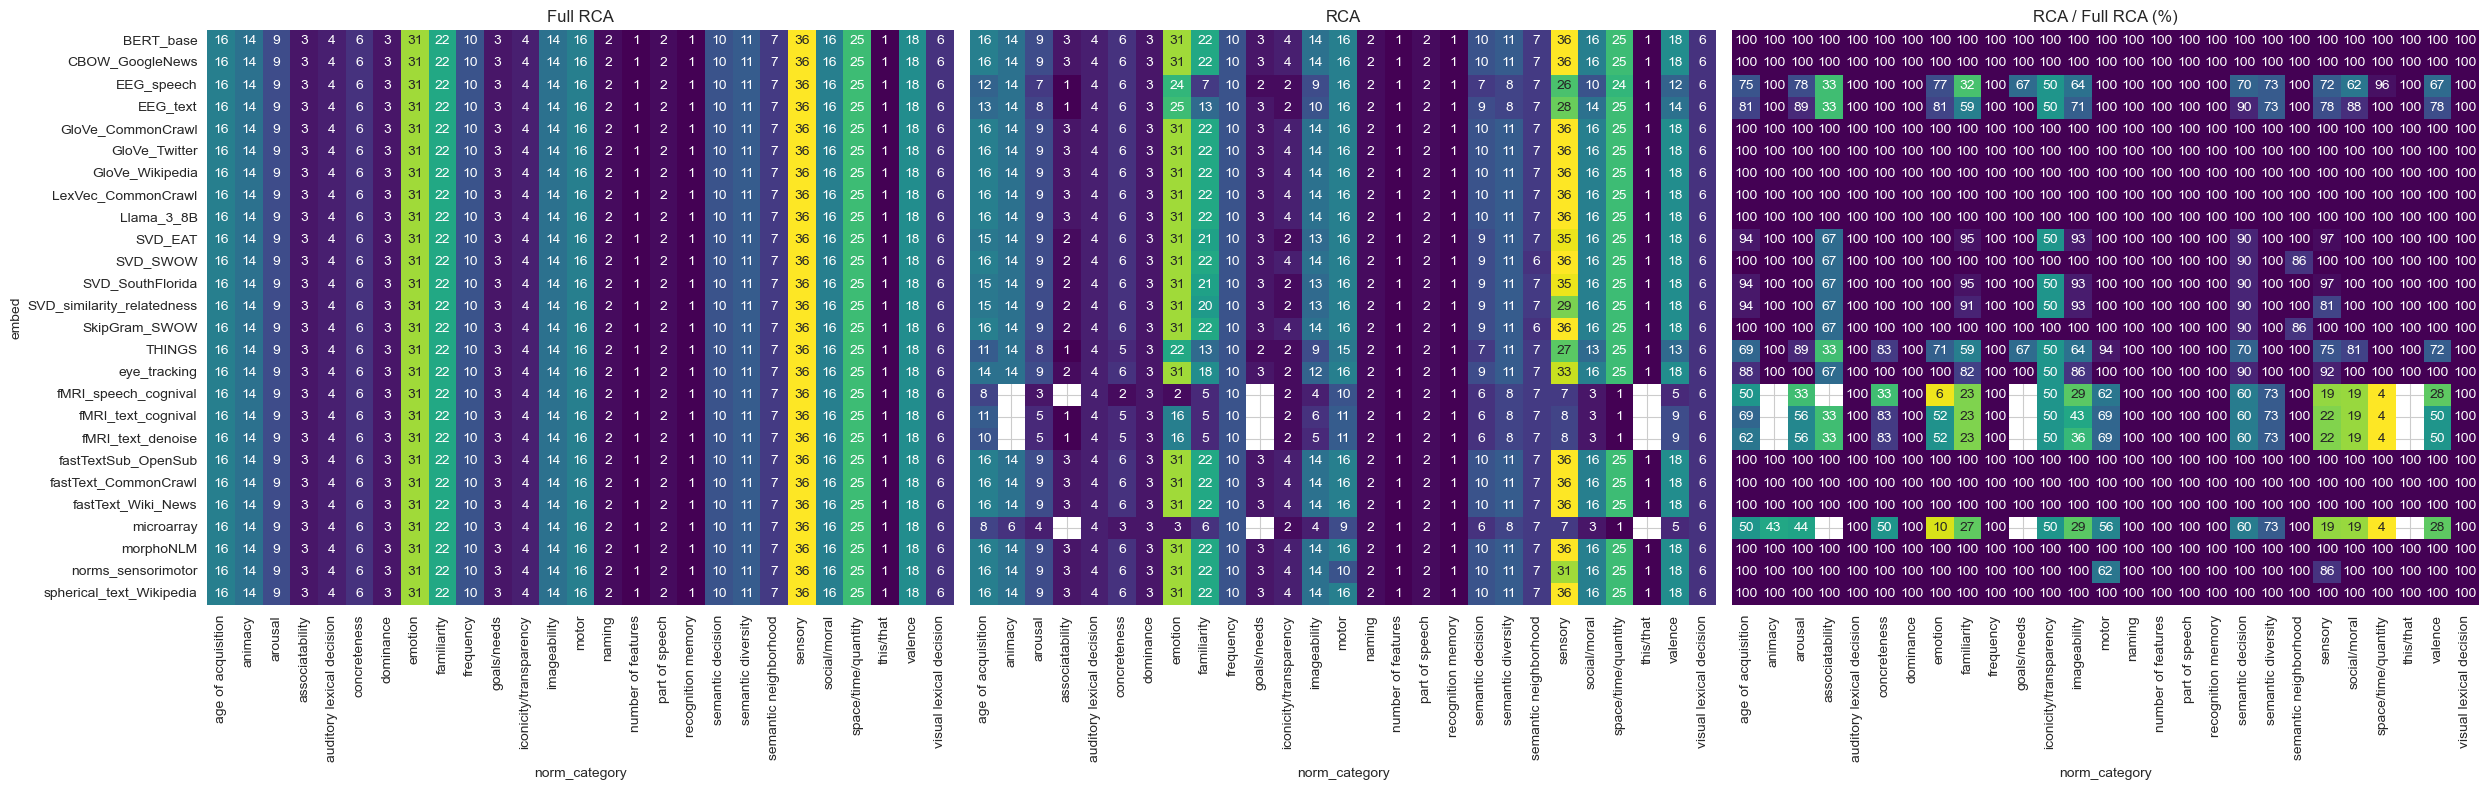

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(25, 8))

sns.heatmap(rca_full_counts, ax=axs[0], cmap='viridis', annot=True, fmt='g', cbar=False)

sns.heatmap(rca_counts, ax=axs[1], cmap='viridis', annot=True, fmt='g', cbar=False)

sns.heatmap(-perc_retained, ax=axs[2], cmap='viridis', annot=perc_retained.round(0), fmt='g', cbar=False)

axs[0].set_title('Full RCA')
axs[1].set_title('RCA')
axs[2].set_title('RCA / Full RCA (%)')

# remove y tick labels for all but the first plot
for ax in axs[1:]:
    ax.set(ylabel='')
    ax.set_yticklabels([])
    
fig.tight_layout()

# Heatmap

In [7]:
with open('../../data/embed_to_dtype.json', 'r') as f:
    embed_to_type = json.load(f)
    
rca['embed_type'] = rca['embed'].map(embed_to_type)
rca

/var/folders/sj/874b9d890dj8vv_y6b9qbzm40000gn/T/ipykernel_13199/1374170505.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rca['embed_type'] = rca['embed'].map(embed_to_type)


,embed,embed_type,norm,train_n,test_n,p,r2_mean,r2_sd,check,norm_category
0,norms_sensorimotor,behavior,frequency_lund,21824,5456,11,0.039306,0.004500,pass,frequency
1,norms_sensorimotor,behavior,frequency_kucera,14486,3622,11,0.029403,0.007545,pass,frequency
2,norms_sensorimotor,behavior,frequency_subtlexus,23015,5754,11,0.068095,0.007467,pass,frequency
3,norms_sensorimotor,behavior,frequency_subtlexuk,23433,5859,11,0.057376,0.005951,pass,frequency
4,norms_sensorimotor,behavior,frequency_blog_gimenes,26140,6536,11,0.065925,0.002942,pass,frequency
...,...,...,...,...,...,...,...,...,...,...
7546,fMRI_text_denoise,brain,body_object_miklashevsky,112,28,128,-0.000461,0.037614,pass,motor
7547,fMRI_text_denoise,brain,aoa_schock,127,32,128,-0.078700,0.053144,pass,age of acquisition
7548,fMRI_text_denoise,brain,aoa_rt_schock,127,32,128,-0.088244,0.065537,pass,semantic decision
7552,fMRI_text_denoise,brain,iconicity_winter2017,321,81,128,-0.108639,0.076285,pass,iconicity/transparency


In [8]:
# rca average
rca_avg = (
    rca[['norm_category', 'embed', 'r2_mean']]
    .groupby(['norm_category', 'embed'], as_index=False).median()
)
rca_avg

,norm_category,embed,r2_mean
0,age of acquisition,BERT_base,0.635169
1,age of acquisition,CBOW_GoogleNews,0.528640
2,age of acquisition,EEG_speech,-0.144143
3,age of acquisition,EEG_text,-0.023821
4,age of acquisition,GloVe_CommonCrawl,0.402782
...,...,...,...
684,visual lexical decision,fastText_Wiki_News,0.136765
685,visual lexical decision,microarray,-0.021854
686,visual lexical decision,morphoNLM,0.287834
687,visual lexical decision,norms_sensorimotor,0.077145


In [9]:
rca_avg_piv = rca_avg.pivot(index='embed', columns='norm_category', values='r2_mean')
rca_avg_piv

norm_category,age of acquisition,animacy,arousal,associatability,auditory lexical decision,concreteness,dominance,emotion,familiarity,frequency,...,recognition memory,semantic decision,semantic diversity,semantic neighborhood,sensory,social/moral,space/time/quantity,this/that,valence,visual lexical decision
embed,,,,,,,,,,,,,,,,,,,,,
BERT_base,0.635169,0.744512,0.574926,0.350088,0.155018,0.808517,0.592024,0.594158,0.394033,0.763021,...,0.424750,0.257822,0.663282,0.296537,0.593317,0.658423,0.582361,0.576716,0.739290,0.427518
CBOW_GoogleNews,0.528640,0.708571,0.540333,0.250240,0.160922,0.704510,0.498838,0.521945,0.316929,0.530482,...,0.374071,0.124298,0.528248,0.182791,0.590521,0.639604,0.517847,0.559614,0.643694,0.366430
EEG_speech,-0.144143,-0.062606,-0.049592,-0.021250,-0.011134,-0.076180,-0.009880,-0.102030,-0.009213,-0.221704,...,-0.007643,-0.152711,-0.174743,-0.055312,-0.061014,-0.081447,-0.069191,-0.089141,-0.031951,-0.026117
EEG_text,-0.023821,-0.186480,-0.038429,-0.038361,-0.003227,-0.078904,-0.006034,-0.019028,-0.039066,-0.077158,...,-0.025770,-0.028762,-0.053622,-0.013118,-0.083851,-0.049937,-0.063821,-0.142636,-0.020548,-0.012064
GloVe_CommonCrawl,0.402782,0.676409,0.501345,-0.082663,0.048584,0.683421,0.499238,0.482841,-0.049688,-0.074540,...,0.253357,-0.012913,-0.012600,0.019044,0.552370,0.661483,0.434408,0.433702,0.639892,0.079491
GloVe_Twitter,0.255263,0.586769,0.428176,-0.044025,-0.005002,0.567716,0.364736,0.358111,0.064170,0.438174,...,0.314946,-0.006513,0.348392,0.054814,0.422093,0.537661,0.378346,0.422850,0.548663,0.132951
GloVe_Wikipedia,0.375740,0.604395,0.361869,0.117255,0.000498,0.574582,0.385444,0.409698,0.065488,0.508448,...,0.240284,-0.003259,0.299916,0.002021,0.422325,0.526845,0.373908,0.422045,0.514625,0.093191
LexVec_CommonCrawl,0.170679,0.696819,0.500268,-0.070276,0.051145,0.678555,0.443872,0.519173,-0.020474,-0.319860,...,0.286514,-0.017370,-0.035206,-0.218411,0.552567,0.626962,0.470007,0.464478,0.606405,0.032936
Llama_3_8B,0.589447,0.765474,0.609161,0.264964,0.190994,0.776136,0.560362,0.607875,0.367935,0.734654,...,0.444559,0.230560,0.599678,0.286307,0.607446,0.658162,0.603575,0.580232,0.702360,0.418720


In [10]:
winner_mask = rca_avg_piv.apply(lambda col: col == col.max(), axis=0)
winner_mask

norm_category,age of acquisition,animacy,arousal,associatability,auditory lexical decision,concreteness,dominance,emotion,familiarity,frequency,...,recognition memory,semantic decision,semantic diversity,semantic neighborhood,sensory,social/moral,space/time/quantity,this/that,valence,visual lexical decision
embed,,,,,,,,,,,,,,,,,,,,,
BERT_base,True,False,False,True,False,True,False,False,True,True,...,False,True,True,True,False,False,False,False,True,True
CBOW_GoogleNews,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
EEG_speech,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
EEG_text,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
GloVe_CommonCrawl,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
GloVe_Twitter,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
GloVe_Wikipedia,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
LexVec_CommonCrawl,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
Llama_3_8B,False,True,False,False,True,False,False,True,False,False,...,True,False,False,False,True,False,True,True,False,False


/var/folders/sj/874b9d890dj8vv_y6b9qbzm40000gn/T/ipykernel_13199/4173034499.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name, 256)  # Get the original colormap


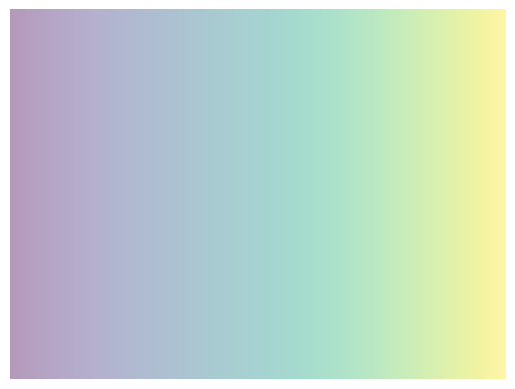

In [11]:
# Function to create a lighter version of a colormap
def lighten_cmap(cmap_name, factor=0.3):
    cmap = plt.cm.get_cmap(cmap_name, 256)  # Get the original colormap
    colors = cmap(np.linspace(0, 1, 256))

    # Blend each color with white
    white = np.array([1, 1, 1, 1])  # RGBA for white
    new_colors = (1 - factor) * colors + factor * white

    return LinearSegmentedColormap.from_list(f'light_{cmap_name}', new_colors)

# Function to visualize a colormap
def plot_colormap(cmap):
    gradient = np.linspace(0, 1, 256)
    gradient = np.vstack((gradient, gradient))

    plt.imshow(gradient, aspect='auto', cmap=cmap)
    plt.axis('off')
    plt.show()

# Usage example:
# Generate a lighter viridis colormap
lighter_viridis = lighten_cmap('viridis', factor=0.6)

# Visualize it
plot_colormap(lighter_viridis)

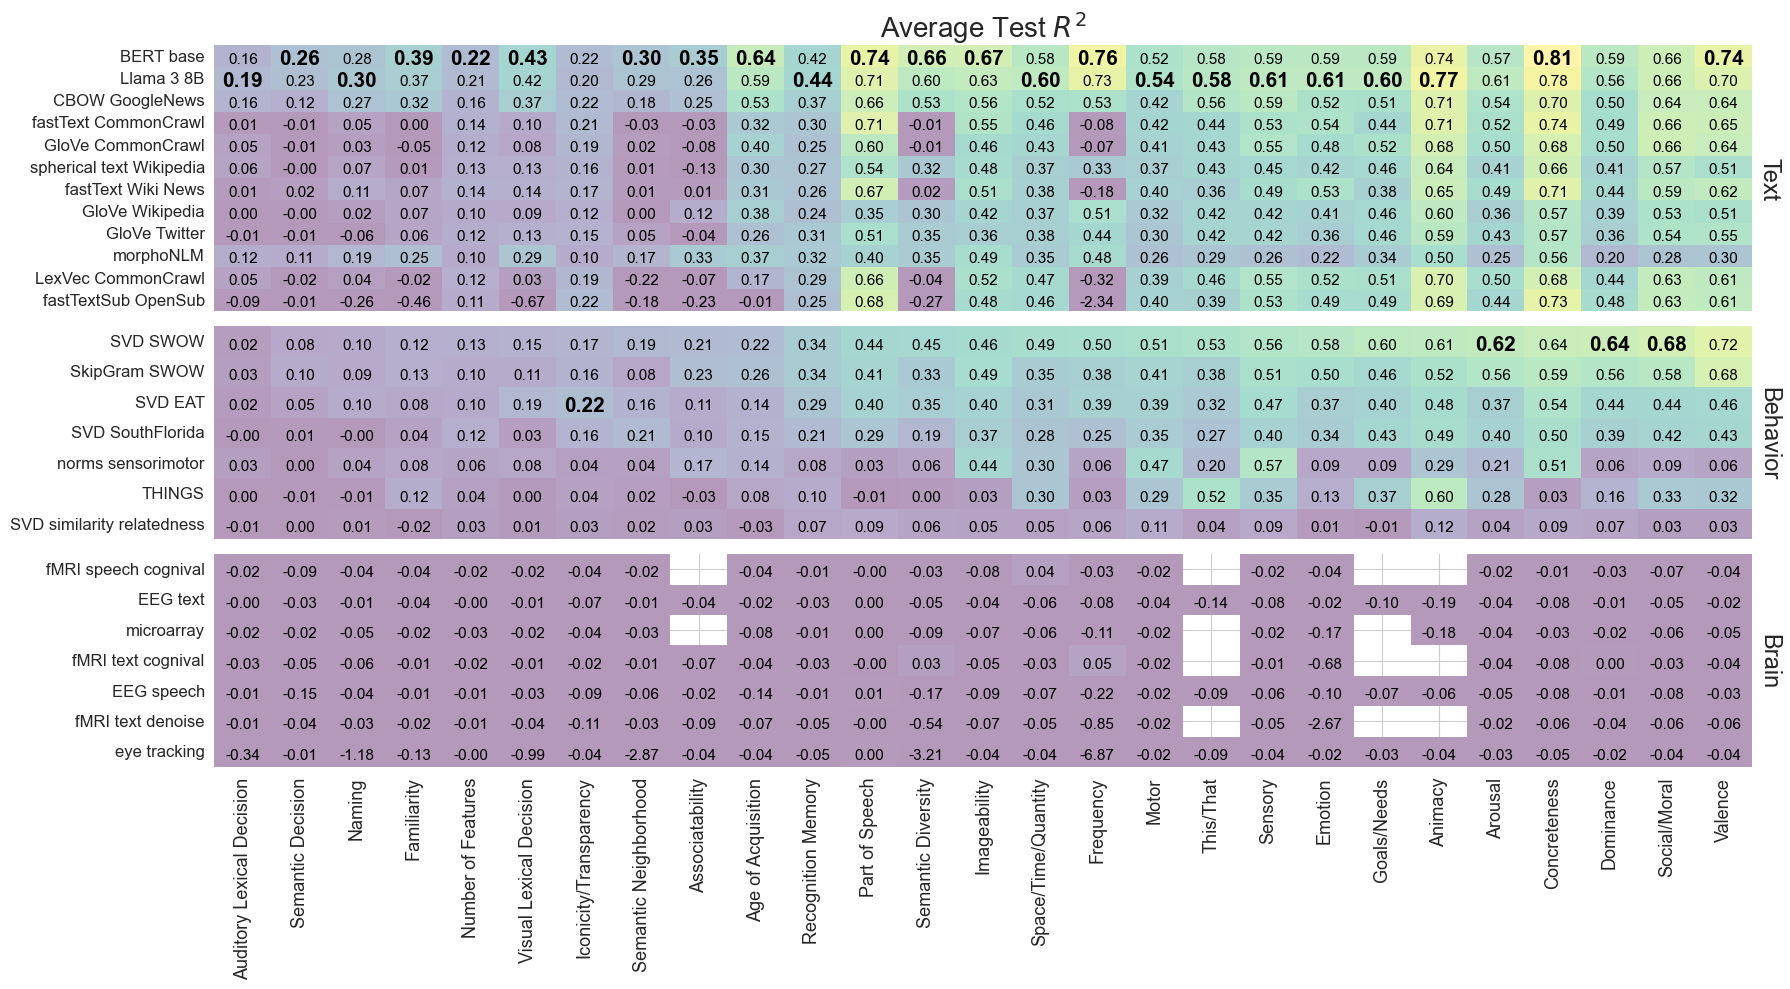

In [12]:
def annotate(df, ax):
    for x, norm_cat in enumerate(df.columns):
        for y, embed in enumerate(df.index):
            annot = df.loc[embed, norm_cat]
            
            # Scientific notation
            if abs(annot) > 1e3:
                annot = f'{annot:.1e}'
            elif np.isnan(annot):
                annot = ''
            else:
                annot = f'{annot:.2f}'
            
            # Fontsize and fontweight
            if winner_mask.loc[embed, norm_cat]:
                fontsize, fontweight = 15, 'bold'
            else:
                fontsize, fontweight = 11, 'normal'
            
            
            ax.text(
                x + .5, y + .6, annot, fontsize=fontsize, fontweight=fontweight,
                ha='center', va='center', color='black'
            )

top_behav = (
    rca_avg_piv[[embed_to_type[embed] == 'behavior' for embed in rca_avg_piv.index]] # Selects behavior embeds
    .mean(axis=1).idxmax() # Selects the behavior embed with the highest average r2
)

# Sorts norms by the average r2 of the top behavior embed
norm_ord = rca_avg_piv.loc[top_behav].sort_values(ascending=True).index

# Builds heatmap dfs
heat_dfs = {}
embed_types = ['text', 'brain', 'behavior']
for embed_type in embed_types:
    heat_df = rca_avg_piv[[embed_to_type[embed] == embed_type for embed in rca_avg_piv.index]]

    # Sorts index and columns
    embed_order = heat_df.mean(axis=1).sort_values(ascending=False).index
    heat_dfs[embed_type] = heat_df[norm_ord].loc[embed_order]

# renaming funct
def fix_names(name: pd.Series) -> pd.Series:
    rename = {}
    return rename.get(name, name).replace('_', ' ')


fig, axs = plt.subplots(3, 1, figsize=(18, 10), height_ratios=[5, 4, 4])

vmax = rca_avg_piv.max().max()
for i, embed_type in enumerate(['text', 'behavior', 'brain']):
    heat_df = heat_dfs[embed_type]
    
    sns.heatmap(
        heat_df, ax=axs[i], vmin=0, cmap=lighter_viridis, 
        vmax=vmax, annot=False, fmt='', cbar=False,
        
    )
    
    
    axs[i].set(xlabel='', xticklabels=[])
    
    # sets ylabel on right-hand side and flips it
    axs[i].set_ylabel(
        embed_type.title(), fontsize=17, rotation=270,
        labelpad=20, va='center', ha='center'
    )
    axs[i].yaxis.set_label_position('right')
    
    # Annotates cells
    annotate(heat_df, axs[i])
    
    
    # Ensure y-axis labels match the number of ticks
    axs[i].set_yticks(pd.Series(range(len(heat_df.index))) + .5)
    heat_df.index = heat_df.index.to_series().apply(fix_names)
    axs[i].set_yticklabels(heat_df.index, fontsize=12)

# Adding xticklabels to last plot
norm_ord = norm_ord.str.title().str.replace(' Of ', ' of ', regex=True)
axs[-1].set_xticklabels(norm_ord, rotation=90, fontsize=13)

# Sets figure title
axs[0].set_title('Average Test ${R^2}$', fontsize=20)
    
fig.tight_layout()
plt.savefig('../../figures/rca.png', dpi=300, bbox_inches='tight')

## Descriptive statistics

In [13]:
rca_avg_piv

norm_category,age of acquisition,animacy,arousal,associatability,auditory lexical decision,concreteness,dominance,emotion,familiarity,frequency,...,recognition memory,semantic decision,semantic diversity,semantic neighborhood,sensory,social/moral,space/time/quantity,this/that,valence,visual lexical decision
embed,,,,,,,,,,,,,,,,,,,,,
BERT_base,0.635169,0.744512,0.574926,0.350088,0.155018,0.808517,0.592024,0.594158,0.394033,0.763021,...,0.424750,0.257822,0.663282,0.296537,0.593317,0.658423,0.582361,0.576716,0.739290,0.427518
CBOW_GoogleNews,0.528640,0.708571,0.540333,0.250240,0.160922,0.704510,0.498838,0.521945,0.316929,0.530482,...,0.374071,0.124298,0.528248,0.182791,0.590521,0.639604,0.517847,0.559614,0.643694,0.366430
EEG_speech,-0.144143,-0.062606,-0.049592,-0.021250,-0.011134,-0.076180,-0.009880,-0.102030,-0.009213,-0.221704,...,-0.007643,-0.152711,-0.174743,-0.055312,-0.061014,-0.081447,-0.069191,-0.089141,-0.031951,-0.026117
EEG_text,-0.023821,-0.186480,-0.038429,-0.038361,-0.003227,-0.078904,-0.006034,-0.019028,-0.039066,-0.077158,...,-0.025770,-0.028762,-0.053622,-0.013118,-0.083851,-0.049937,-0.063821,-0.142636,-0.020548,-0.012064
GloVe_CommonCrawl,0.402782,0.676409,0.501345,-0.082663,0.048584,0.683421,0.499238,0.482841,-0.049688,-0.074540,...,0.253357,-0.012913,-0.012600,0.019044,0.552370,0.661483,0.434408,0.433702,0.639892,0.079491
GloVe_Twitter,0.255263,0.586769,0.428176,-0.044025,-0.005002,0.567716,0.364736,0.358111,0.064170,0.438174,...,0.314946,-0.006513,0.348392,0.054814,0.422093,0.537661,0.378346,0.422850,0.548663,0.132951
GloVe_Wikipedia,0.375740,0.604395,0.361869,0.117255,0.000498,0.574582,0.385444,0.409698,0.065488,0.508448,...,0.240284,-0.003259,0.299916,0.002021,0.422325,0.526845,0.373908,0.422045,0.514625,0.093191
LexVec_CommonCrawl,0.170679,0.696819,0.500268,-0.070276,0.051145,0.678555,0.443872,0.519173,-0.020474,-0.319860,...,0.286514,-0.017370,-0.035206,-0.218411,0.552567,0.626962,0.470007,0.464478,0.606405,0.032936
Llama_3_8B,0.589447,0.765474,0.609161,0.264964,0.190994,0.776136,0.560362,0.607875,0.367935,0.734654,...,0.444559,0.230560,0.599678,0.286307,0.607446,0.658162,0.603575,0.580232,0.702360,0.418720


In [14]:
# Embedding-wise medians
embed_medians = pd.DataFrame(rca_avg_piv.median(axis=1))
embed_medians['dtype'] = embed_medians.index.map(embed_to_type)
embed_medians.columns = ['median', 'dtype']
embed_medians

,median,dtype
embed,,
BERT_base,0.582361,text
CBOW_GoogleNews,0.517847,text
EEG_speech,-0.061014,brain
EEG_text,-0.038429,brain
GloVe_CommonCrawl,0.410165,text
GloVe_Twitter,0.358111,text
GloVe_Wikipedia,0.361869,text
LexVec_CommonCrawl,0.394320,text
Llama_3_8B,0.589447,text


In [15]:
# Grouping by dtype and computing the median, 1st and 3rd quartiles
dtype_medians = embed_medians.groupby('dtype').agg(
    median=('median', 'median'),
    first_quartile=('median', lambda x: x.quantile(0.25)),
    third_quartile=('median', lambda x: x.quantile(0.75))
)
dtype_medians.round(2).sort_values(by='median', ascending=False)

,median,first_quartile,third_quartile
dtype,,,
text,0.39,0.36,0.45
behavior,0.27,0.08,0.36
brain,-0.04,-0.05,-0.03


## Comparing performance of the best-performing embeds from each type

In [16]:
rca_avg['embed_type'] = rca_avg['embed'].map(embed_to_type)

# Taking the best-performing embed from each type
rca_grand_avg = (
    rca_avg.groupby(['embed_type', 'norm_category'], as_index=False).max()
    .rename(columns={'r2_mean': 'r2_max'})
)
rca_grand_avg

,embed_type,norm_category,embed,r2_max
0,behavior,age of acquisition,norms_sensorimotor,0.255921
1,behavior,animacy,norms_sensorimotor,0.606707
2,behavior,arousal,norms_sensorimotor,0.618196
3,behavior,associatability,norms_sensorimotor,0.232700
4,behavior,auditory lexical decision,norms_sensorimotor,0.032263
...,...,...,...,...
76,text,social/moral,spherical_text_Wikipedia,0.661483
77,text,space/time/quantity,spherical_text_Wikipedia,0.603575
78,text,this/that,spherical_text_Wikipedia,0.580232
79,text,valence,spherical_text_Wikipedia,0.739290


In [17]:
# Top and bottom norms reported in the paper
rca_grand_avg = rca_grand_avg.pivot(columns='norm_category', index='embed_type', values='r2_max').T
rca_grand_avg['behavior - text'] = rca_grand_avg['behavior'] - rca_grand_avg['text']
rca_grand_avg = rca_grand_avg.sort_values(by='behavior - text', ascending=True).round(2)
rca_grand_avg

embed_type,behavior,brain,text,behavior - text
norm_category,,,,
age of acquisition,0.26,-0.02,0.64,-0.38
part of speech,0.44,0.01,0.74,-0.29
familiarity,0.13,-0.01,0.39,-0.27
frequency,0.50,0.05,0.76,-0.26
visual lexical decision,0.19,-0.01,0.43,-0.24
semantic diversity,0.45,0.03,0.66,-0.22
naming,0.10,-0.01,0.30,-0.20
imageability,0.49,-0.04,0.67,-0.18
concreteness,0.64,-0.01,0.81,-0.17
